# Uogólniona transformata Hougha

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## R-table

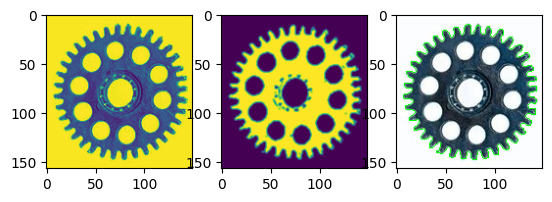

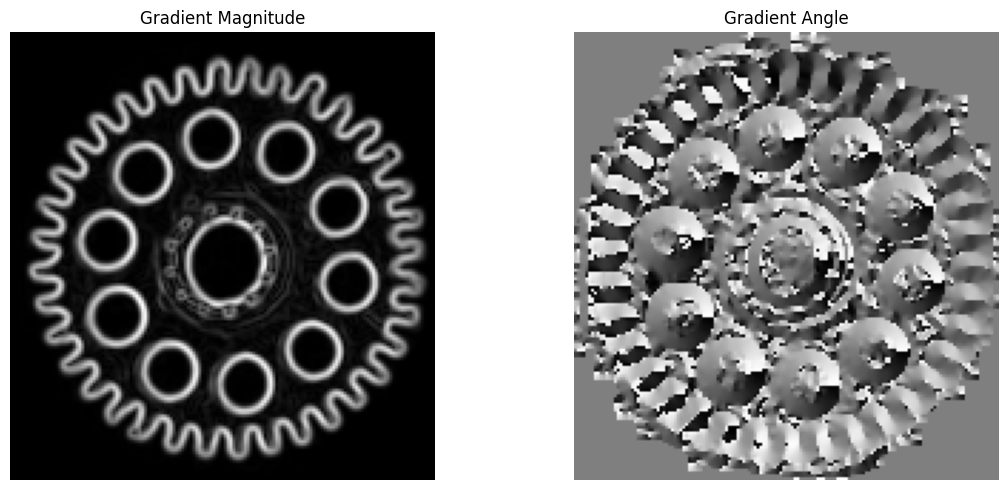

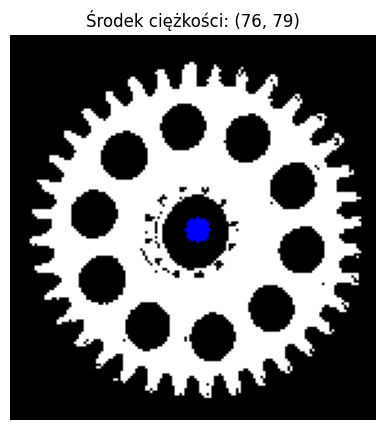

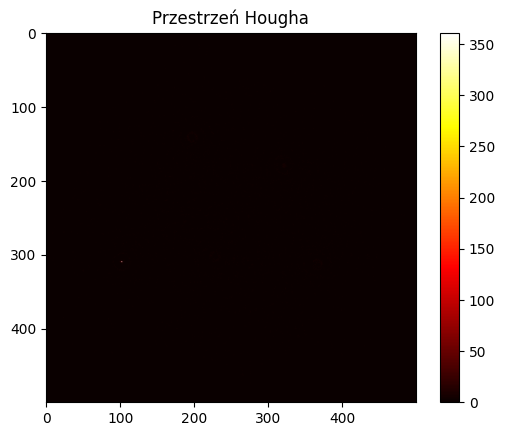

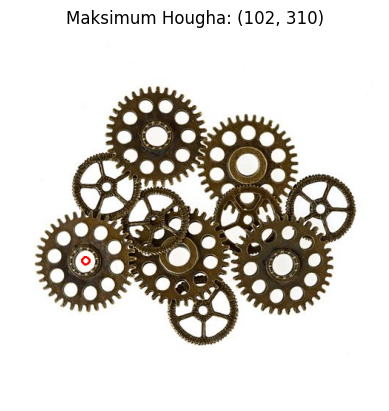

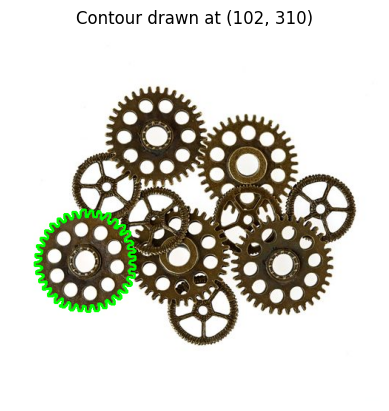

In [15]:
class RTableHought:

    def __init__(self):
        pass

    def get_contour(self, img, threshold, visualize=False):
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        v, binary_img = cv2.threshold(gray_img, threshold, 255, cv2.THRESH_BINARY_INV)
        binary_img = cv2.GaussianBlur(binary_img, (3, 3), 1)
        contours, hierarchy = cv2.findContours(
            binary_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE
        )

        if visualize:
            img_contour = cv2.drawContours(img.copy(), contours, 0, (0, 255, 0))
            fig, ax = plt.subplots(1, 3)
            ax[0].imshow(gray_img)
            ax[1].imshow(binary_img)
            ax[2].imshow(img_contour)

        self.contour = contours[0]

        return contours[0]

    def get_gradient(self, img, visualize=False, threshold=False):

        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        dX = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=5)
        dY = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=5)
        
        # Gradient magnitude
        magnitude = np.sqrt(dX**2 + dY**2)
        angle = (np.arctan2(dY, dX)*180/np.pi)
        
        # Normalize magnitude to 0-255
        

        if visualize:
            distance = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.title("Gradient Magnitude")
            plt.imshow(cv2.cvtColor(distance, cv2.COLOR_GRAY2BGR))
            plt.axis('off')


            vis_angle = cv2.normalize(np.arctan2(dY, dX), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            plt.subplot(1, 2, 2)
            plt.title("Gradient Angle")
            plt.imshow(cv2.cvtColor(vis_angle, cv2.COLOR_GRAY2BGR))  # HSV for direction visualization
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        return angle, magnitude

    def get_refpoint(self, img, threshold, visualize=False):
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary_img = cv2.threshold(gray_img, threshold, 255, cv2.THRESH_BINARY_INV)
        moments = cv2.moments(binary_img, 1)
        
        x_c = int(moments["m10"] / moments["m00"])
        y_c = int(moments["m01"] / moments["m00"])
        
        if visualize:
            img_vis = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)
            cv2.circle(img_vis, (x_c, y_c), 5, (0, 0, 255), -1)  # Red dot

            plt.figure(figsize=(5, 5))
            plt.imshow(img_vis)
            plt.title(f"Środek ciężkości: ({x_c}, {y_c})")
            plt.axis("off")
            plt.show()

        return (x_c, y_c)

    def populate_reftable(self, refpoint, contour, gradient):

        Rtable = [[] for _ in range (360)]
        grad_angle = gradient[0].astype(int)

        for cont_point in contour:
            x, y = cont_point[0]
            point_angle = int(grad_angle[y, x]) % 360

            ref_dX = refpoint[0] - x
            ref_dY = refpoint[1] - y

            ref_angle = np.arctan2(ref_dY, ref_dX) * 180 / np.pi
            ref_distance = np.sqrt(ref_dX**2 + ref_dY**2)

            Rtable[point_angle].append((ref_angle, ref_distance))

        return Rtable

    def Rtable_Pipe(self, img, threshold, visualize):
        contour = self.get_contour(img, threshold, visualize)
        gradient = self.get_gradient(img, visualize)
        refpoint = self.get_refpoint(img, threshold, visualize)
        Rtable = self.populate_reftable(refpoint, contour, gradient)
        return Rtable

    def populate_hough_space(self, img, Rtable, visualize=True):
        angle, magnitude = self.get_gradient(img)
        h, w = img.shape[:2]
        H = np.zeros((h, w), dtype=np.uint32)  # przestrzeń Hougha

        # Normalizujemy magnitude do wartości [0, 1] przed progowaniem
        magnitude_norm = cv2.normalize(magnitude, None, 0, 1.0, cv2.NORM_MINMAX)

        for y in range(h):
            for x in range(w):
                if magnitude_norm[y, x] > 0.5:
                    phi = int(angle[y, x]) % 360  # upewnij się że kąt jest z przedziału [0, 359]

                    for r_angle, r_dist in Rtable[phi]:
                        # Zamiana kąta na radiany
                        alpha_rad = np.radians(r_angle)

                        x1 = int(x + r_dist * np.cos(alpha_rad))
                        y1 = int(y + r_dist * np.sin(alpha_rad))

                        if 0 <= x1 < w and 0 <= y1 < h:
                            H[y1, x1] += 1

        if visualize:
            plt.imshow(H, cmap='hot')
            plt.title("Przestrzeń Hougha")
            plt.colorbar()
            plt.show()

        return H
    
    def mark_hough_max(self, img, H, visualize=True):

        # Znajdź współrzędne maksimum
        M = np.where(H == H.max())
        m_y, m_x = int(M[0][0]), int(M[1][0])

        # Zrób kopię obrazu i zaznacz maksimum czerwonym kółkiem
        img_marked = img.copy()
        img_marked = cv2.circle(img_marked, (m_x, m_y), 5, (0, 0, 255), 2)  # (x, y)

        if visualize:
            plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
            plt.title(f"Maksimum Hougha: ({m_x}, {m_y})")
            plt.axis('off')
            plt.show()

        return m_x, m_y
    
    def draw_contour_at_location(self, img, coordinates, color=(0, 255, 0), thickness=2, visualize=True):

        contour = self.contour
        # Calculate center of original contour
        moments = cv2.moments(contour)
        cX = int(moments["m10"] / moments["m00"])
        cY = int(moments["m01"] / moments["m00"])

        # Compute translation vector
        dx = coordinates[0] - cX
        dy = coordinates[1] - cY

        # Translate contour
        translated_contour = contour + np.array([[[dx, dy]]], dtype=np.int32)

        # Draw on a copy of the image
        img_out = img.copy()
        cv2.drawContours(img_out, [translated_contour], -1, color, thickness)

        if visualize:
            plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
            plt.title(f"Contour drawn at {coordinates}")
            plt.axis('off')
            plt.show()

        return img_out




rtable_hough = RTableHought()

trybik = cv2.imread("trybik.jpg")
trybikiii = cv2.imread("trybiki2.jpg")

# rtable_hough.get_contour(trybik, 128, True)

# rtable_hough.get_gradient(trybik, True)

Rtable = rtable_hough.Rtable_Pipe(trybik, 128, True)

H_space = rtable_hough.populate_hough_space(trybikiii, Rtable, True)

cords = rtable_hough.mark_hough_max(trybikiii, H_space, True)

x = rtable_hough.draw_contour_at_location(trybikiii, cords, )